In [1]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# model evaluate
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RepeatedKFold, cross_val_score

In [2]:
training_df = pd.read_csv("../datasets/training.csv")
training_df.set_index("date", inplace=True)
X_train = training_df.iloc[:,1:]
y_train = training_df.Appliances
X_train

,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.00,45.566667,17.166667,...,18.2000,48.900000,17.033333,45.530000,6.600000,733.5,92.000000,7.000000,63.000000,5.300000
2016-01-11 17:10:00,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.00,45.992500,17.166667,...,18.2000,48.863333,17.066667,45.560000,6.483333,733.6,92.000000,6.666667,59.166667,5.200000
2016-01-11 17:30:00,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.89,45.723333,17.166667,...,18.1000,48.590000,17.000000,45.400000,6.250000,733.8,92.000000,6.000000,51.500000,5.000000
2016-01-11 17:40:00,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.89,45.530000,17.200000,...,18.1000,48.590000,17.000000,45.400000,6.133333,733.9,92.000000,5.666667,47.666667,4.900000
2016-01-11 17:50:00,40,19.890000,46.026667,19.200000,44.500000,19.790000,44.933333,18.89,45.730000,17.133333,...,18.1000,48.590000,17.000000,45.290000,6.016667,734.0,92.000000,5.333333,43.833333,4.800000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-05-27 17:00:00,0,25.600000,47.193333,25.968571,42.528571,27.390000,41.030000,24.70,45.626667,23.200000,...,24.6000,50.863333,23.200000,46.751429,23.000000,755.2,55.000000,3.000000,22.000000,13.400000
2016-05-27 17:20:00,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.70,45.590000,23.200000,...,24.7000,50.074000,23.200000,46.790000,22.733333,755.2,55.666667,3.333333,23.666667,13.333333
2016-05-27 17:30:00,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.70,45.590000,23.230000,...,24.7000,49.790000,23.200000,46.790000,22.600000,755.2,56.000000,3.500000,24.500000,13.300000


In [3]:
models = {
    "LR": LinearRegression(n_jobs=-1),
    "RF": RandomForestRegressor(n_estimators=300, max_features=18, n_jobs=-1, verbose=1, random_state=1337),
    "GBM": GradientBoostingRegressor(n_estimators=1200, max_depth=5, random_state=1337, verbose=1),
}

rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1337)

In [4]:
training_results = {}
means = []
cis = []

for name, model in models.items():
    start = time.time()
    print("#########", name, "#########")
    
    neg_rmse_scores = cross_val_score(model, X_train, y_train, cv=rkf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    rmse_scores = -neg_rmse_scores
    mean_rmse = rmse_scores.mean()
    std_rmse = rmse_scores.std()
    
    ci95 = 1.96 * std_rmse / np.sqrt(len(rmse_scores))

    training_results[name] = mean_rmse
    means.append(mean_rmse)
    cis.append(ci95)

    end = time.time()
    print(np.round(rmse_scores, 3)) 
    print(f"-> Runtime: {end-start:.3f} seconds, Mean RMSE: {np.round(mean_rmse, 3)}, 95% CI: ±{np.round(ci95, 2)}\n")

######### LR #########
[ 94.234  94.151  87.045  84.367 101.149  90.718  99.48   89.221  97.187
  97.768  87.527  91.569  88.36  104.043 102.328  90.564  88.529  92.737
  99.057  90.226  96.605  86.106  85.81   97.608 102.328  92.121  90.723
  92.186  98.202  93.888]
-> Runtime: 2.828 seconds, Mean RMSE: 93.528, 95% CI: ±1.92

######### RF #########


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs

[72.887 75.05  66.913 63.714 80.626 66.969 76.469 67.402 73.491 75.078
 66.525 74.207 65.814 75.774 73.855 67.941 68.892 72.186 76.968 69.598
 70.545 71.646 62.9   73.183 76.837 68.742 71.275 68.996 78.308 69.128]
-> Runtime: 220.464 seconds, Mean RMSE: 71.397, 95% CI: ±1.56

######### GBM #########
[72.233 78.213 70.451 63.233 78.063 69.762 74.447 66.001 69.539 75.697
 65.754 75.578 65.984 73.34  70.713 69.243 68.429 72.481 75.056 69.882
 72.072 68.41  62.015 72.531 75.597 71.135 71.386 65.967 78.824 68.384]
-> Runtime: 426.302 seconds, Mean RMSE: 71.014, 95% CI: ±1.52



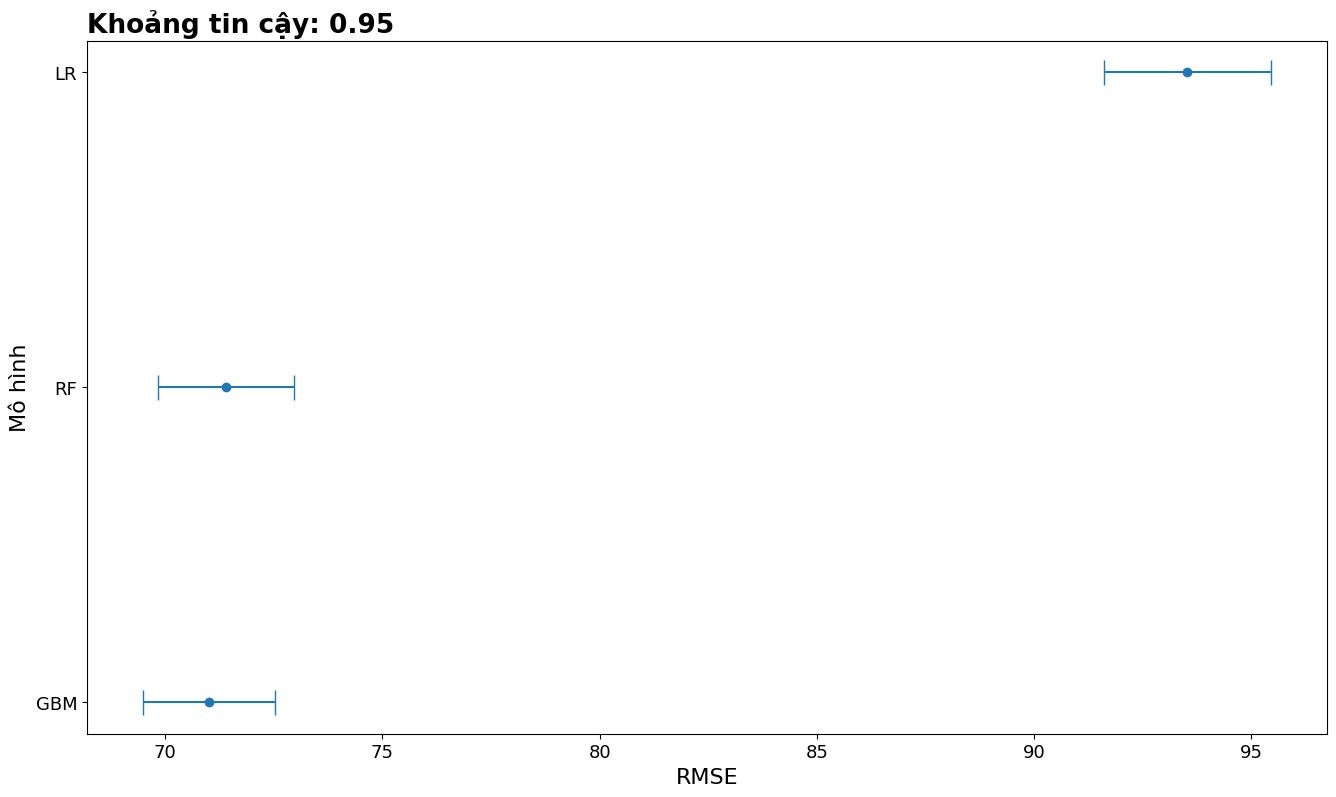

In [11]:
model_names = list(models.keys())
y_pos = np.arange(len(model_names))[::-1]

plt.figure(figsize=(16, 9))
plt.title("Khoảng tin cậy: 0.95", fontweight="bold", loc="left", fontsize=19)
plt.xlabel("RMSE", fontsize=16)
plt.xticks(fontsize=13)
plt.ylabel("Mô hình", fontsize=16)
plt.yticks(y_pos, model_names, fontsize=13)

plt.errorbar(means, y_pos, xerr=cis, fmt="o", capsize=9)
plt.savefig("../fig/RMSE_fig9.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
rf.feature_importances_

NameError: name 'rf' is not defined